ЭТАП 1: Анализ данных (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score
import joblib

In [3]:
# Загрузить CSV и вывести первые 10 строк.
df = pd.read_csv('diabetes.csv')
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
# Вывести .info(), .shape(), .describe().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# размер
df.shape

(768, 9)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Проверить на наличие дубликатов и нечисловых значений.
df.duplicated().sum()

np.int64(0)

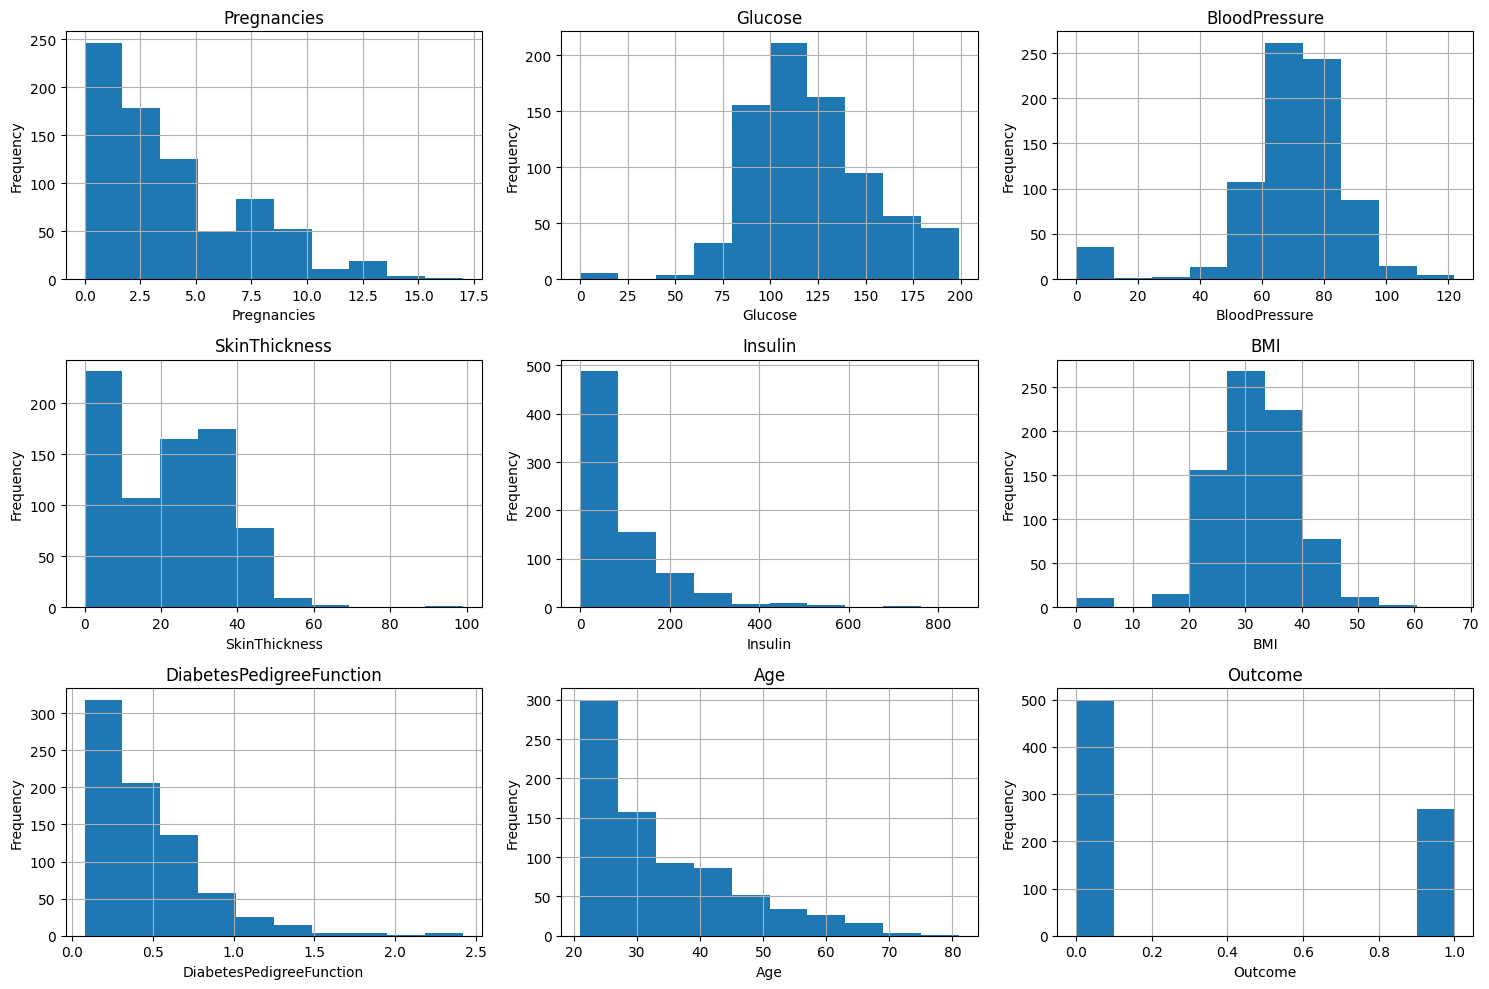

In [8]:
# Построить распределения (histogram) по числовым признакам.
df_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, (col, ax) in enumerate(zip(df_columns, axes)):
    df[col].hist(ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [41]:
# Среднее/медиана по Glucose, BMI, Age, Insulin.
df[['Glucose', 'BMI', 'Age', 'Insulin']].agg(['mean', 'median'])

,Glucose,BMI,Age,Insulin
mean,121.686763,32.457464,33.240885,155.548223
median,117.000000,32.400000,29.000000,155.548223


In [42]:
# Кол-во пациентов с Glucose < 70.
count_glucose_lt_70 = len(df[df['Glucose'] < 70])
print(f"Количество пациентов с Glucose < 70: {count_glucose_lt_70}")

Количество пациентов с Glucose < 70: 11


In [43]:
# Кол-во пациентов с BMI > 40 (ожирение 3-й степени).
count_bmi_gt_40 = len(df[df['BMI'] > 40])
print(f"Количество пациентов с BMI > 40: {count_bmi_gt_40}")

Количество пациентов с BMI > 40: 96


In [44]:
# Распределение по Pregnancies — value_counts().
df['Pregnancies'].value_counts().sort_index()

,count
Pregnancies,
0,111
1,135
2,103
3,75
4,68
5,57
6,50
7,45
8,38


In [46]:
# Распределение целевой переменной Outcome.
outcome_dist = df['Outcome'].value_counts()
print(outcome_dist)

Outcome
0    500
1    268
Name: count, dtype: int64


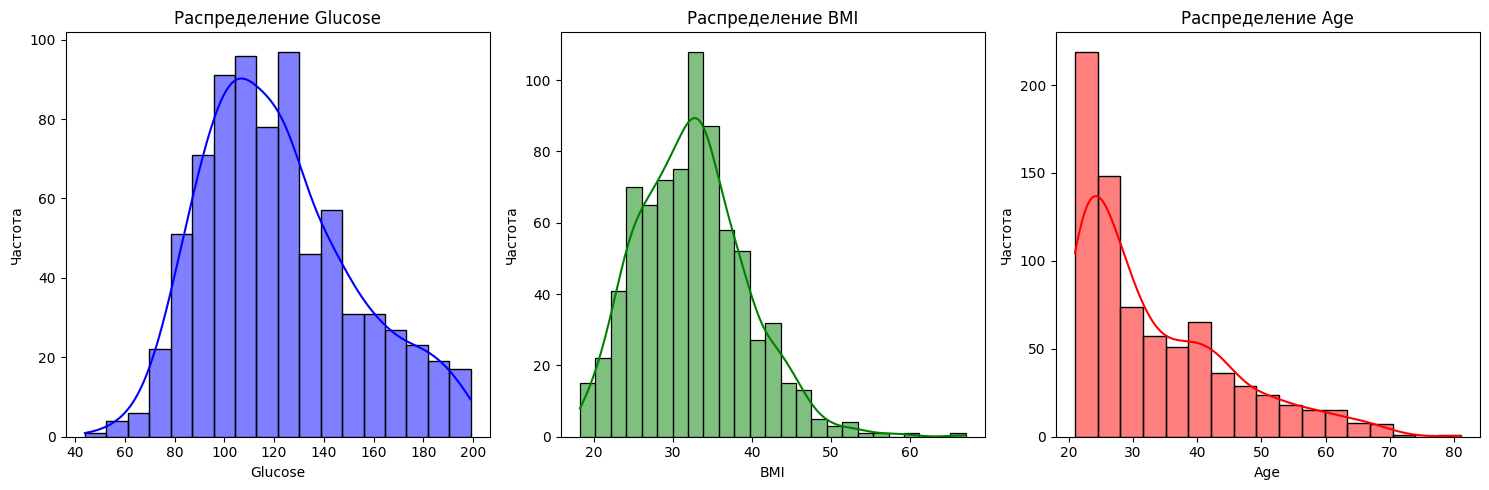

In [47]:
# distplot / hist по Glucose, BMI, Age.
plt.figure(figsize=(15, 5))

# Гистограмма для Glucose
plt.subplot(1, 3, 1)
sns.histplot(df['Glucose'], kde=True, color='blue')
plt.title('Распределение Glucose')
plt.xlabel('Glucose')
plt.ylabel('Частота')

# Гистограмма для BMI
plt.subplot(1, 3, 2)
sns.histplot(df['BMI'], kde=True, color='green')
plt.title('Распределение BMI')
plt.xlabel('BMI')
plt.ylabel('Частота')

# Гистограмма для Age
plt.subplot(1, 3, 3)
sns.histplot(df['Age'], kde=True, color='red')
plt.title('Распределение Age')
plt.xlabel('Age')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

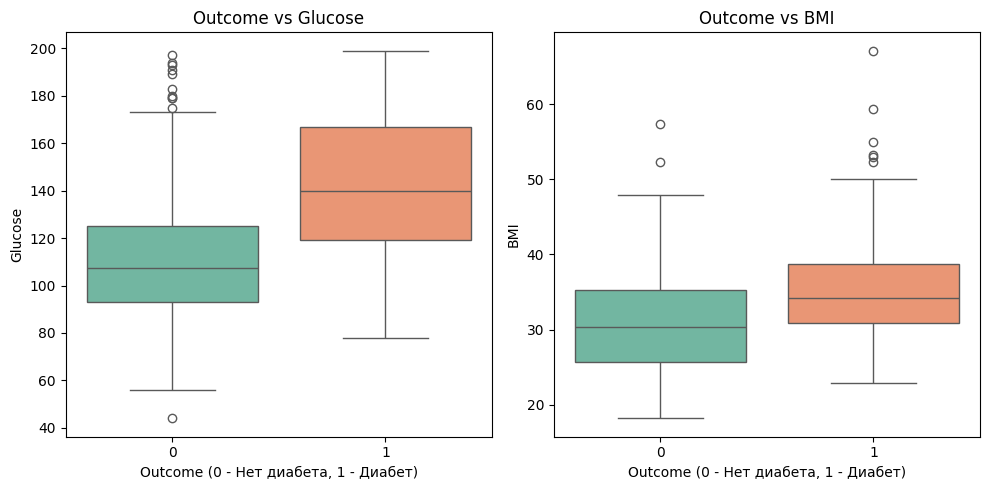

In [49]:
# Boxplot: Outcome vs BMI, Glucose.
plt.figure(figsize=(10, 5))

# Boxplot для Outcome vs Glucose
plt.subplot(1, 2, 1)
sns.boxplot(x='Outcome', y='Glucose', hue='Outcome', data=df, palette='Set2', legend=False)
plt.title('Outcome vs Glucose')
plt.xlabel('Outcome (0 - Нет диабета, 1 - Диабет)')
plt.ylabel('Glucose')

# Boxplot для Outcome vs BMI
plt.subplot(1, 2, 2)
sns.boxplot(x='Outcome', y='BMI', hue='Outcome', data=df, palette='Set2', legend=False)
plt.title('Outcome vs BMI')
plt.xlabel('Outcome (0 - Нет диабета, 1 - Диабет)')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

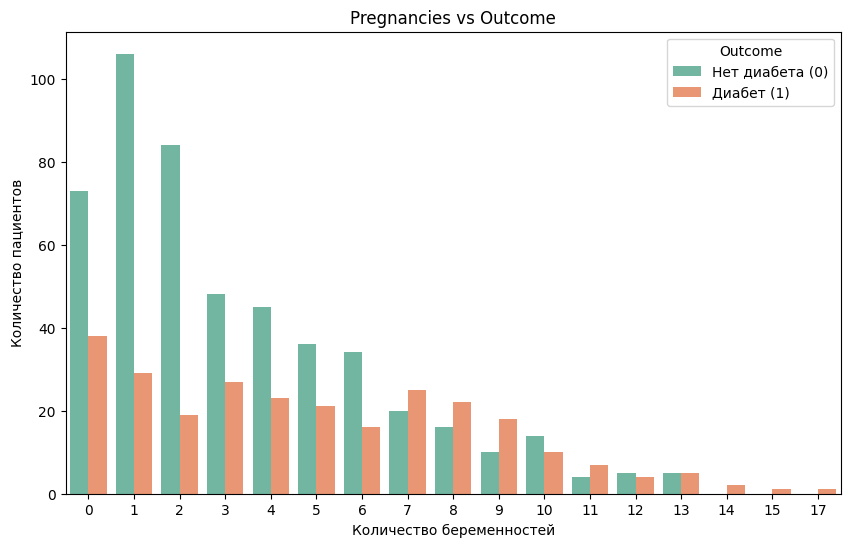

In [50]:
# Barplot: Pregnancies vs Outcome.
plt.figure(figsize=(10, 6))
sns.countplot(x='Pregnancies', hue='Outcome', data=df, palette='Set2')
plt.title('Pregnancies vs Outcome')
plt.xlabel('Количество беременностей')
plt.ylabel('Количество пациентов')
plt.legend(title='Outcome', labels=['Нет диабета (0)', 'Диабет (1)'])
plt.show()

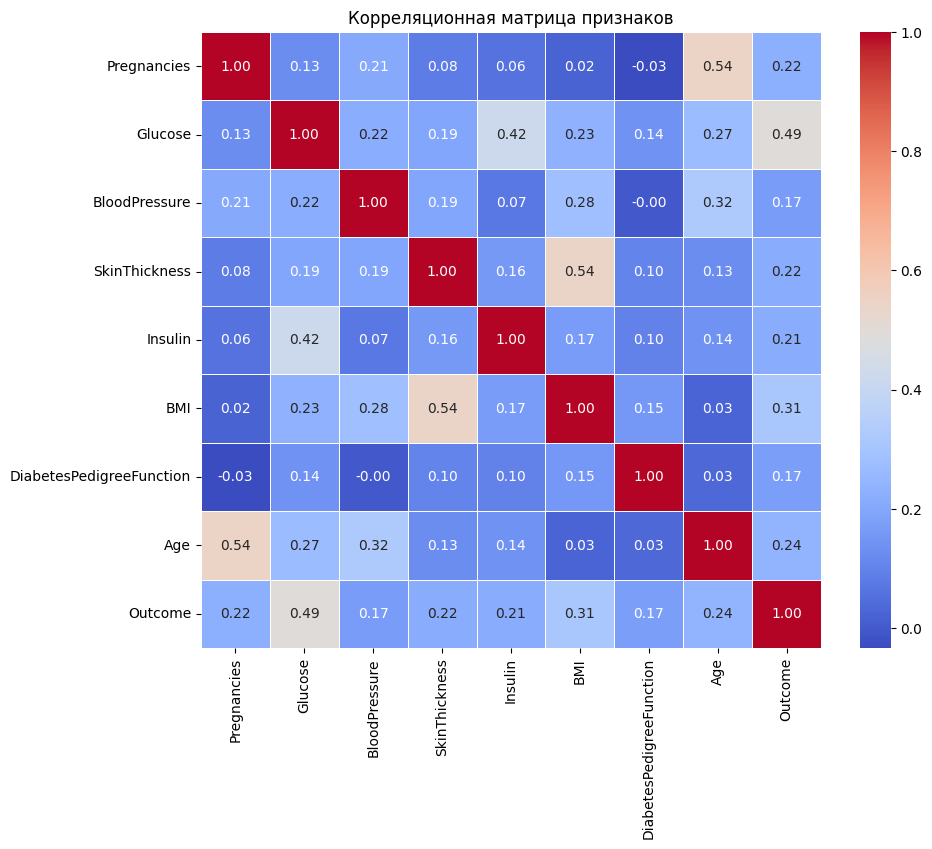

In [51]:
# Корреляционная матрица + heatmap.
# Вычисление корреляционной матрицы
corr_matrix = df.corr()

# Построение тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

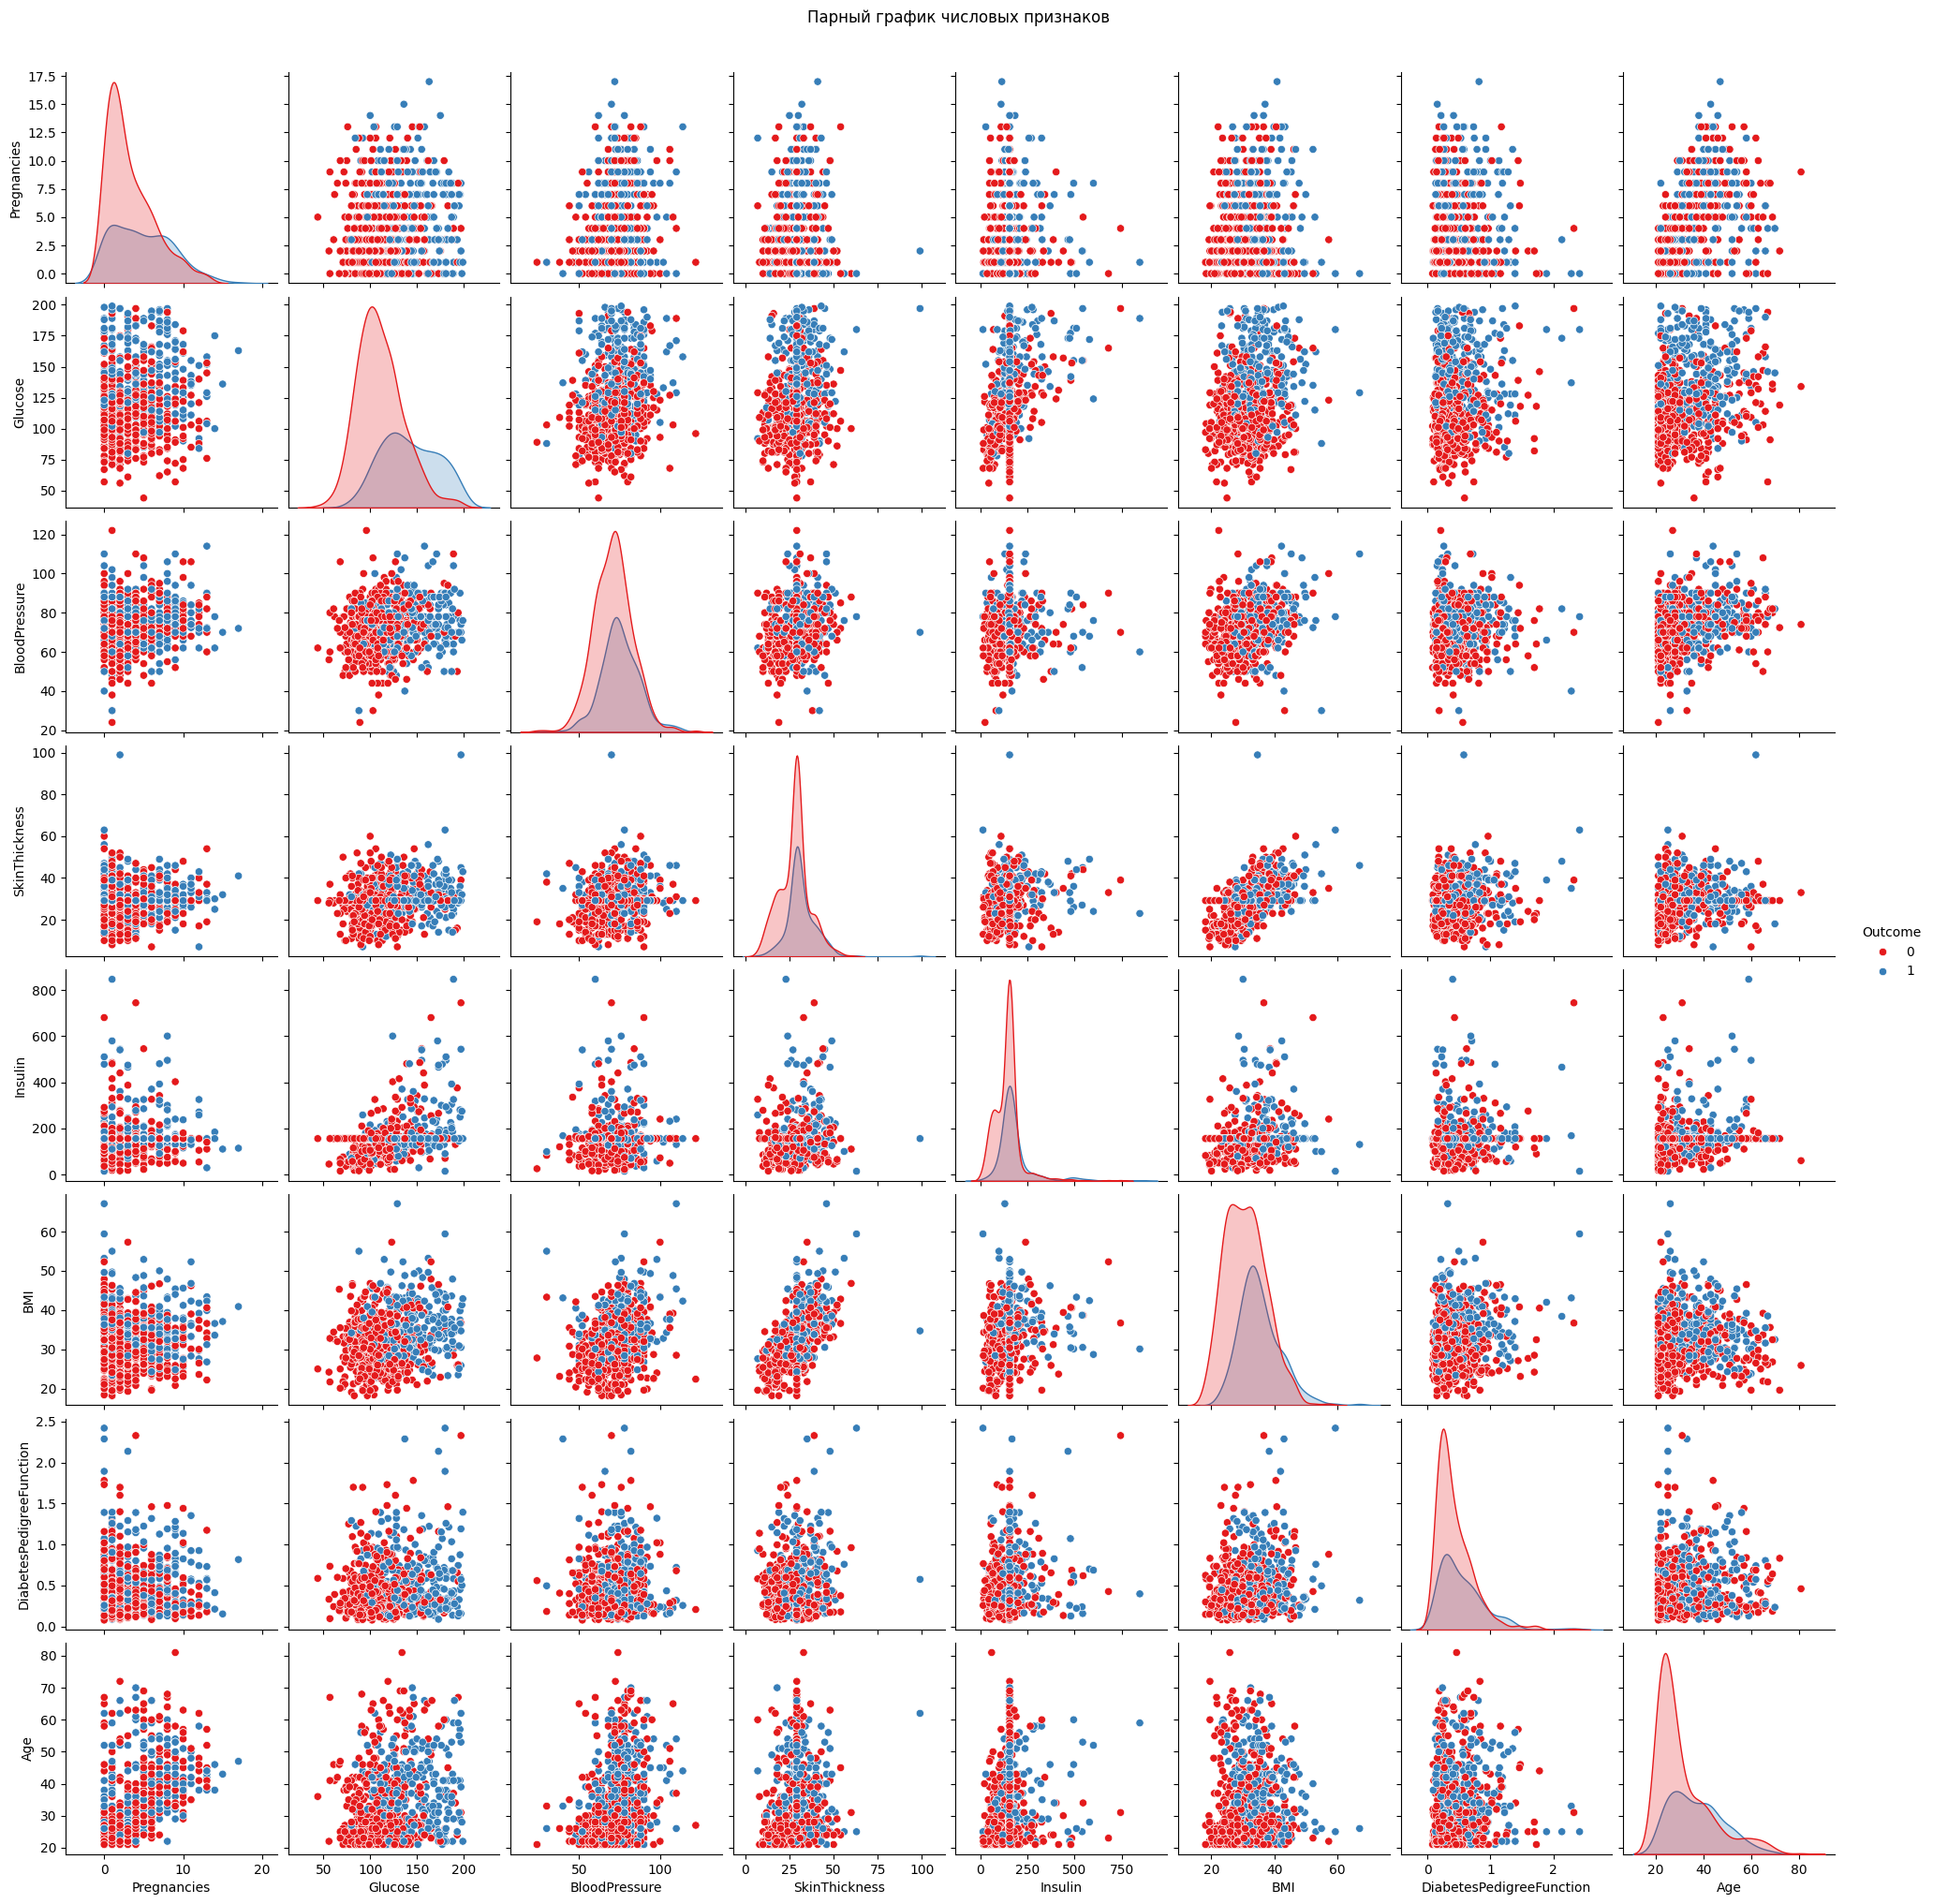

In [52]:
# Pairplot по числовым признакам.
sns.pairplot(df, hue='Outcome', vars=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], palette='Set1')
plt.suptitle('Парный график числовых признаков', y=1.02)
plt.show()

********************

************************

ЭТАП 2: Предобработка данных

In [19]:
# Проверка пропущенных значений (ноль ≠ null).
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [20]:
# Обработка нулевых значений (например, SkinThickness, Insulin):
new_df = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]
for i in new_df:
    print(f'{i} = {(df[i] == 0).sum()}')

Glucose = 5
BloodPressure = 35
SkinThickness = 227
Insulin = 374
BMI = 11


In [21]:
# нольдорду null кылабыз, нольдор обработка болбогонго байланыштуу
for i in new_df:
    df[i] = df[i].replace(0, np.nan)

In [22]:
# Проверка пропущенных значений (ноль ≠ null).
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [23]:
# нольдордун оордун null менен толтуруу
for i in new_df:
    df[i] = df[i].fillna(df[i].mean())

In [24]:
# Масштабирование числовых признаков через StandardScaler.
scaler = StandardScaler()
features = df.drop(columns=['Outcome'])
scaled_data = scaler.fit_transform(features)

In [25]:
# проверка данных
scaled_data

array([[ 0.63994726,  0.86510807, -0.03351824, ...,  0.16629174,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20616153, -0.52985903, ..., -0.85253118,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.0158134 , -0.69530596, ..., -1.33283341,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.0225789 , -0.03351824, ..., -0.91074963,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14180757, -1.02619983, ..., -0.34311972,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94314317, -0.19896517, ..., -0.29945588,
        -0.47378505, -0.87137393]])

In [26]:
# Определение X (все признаки) и y = Outcome.
x = scaled_data
y = df['Outcome']

In [27]:
# Разделение train/test: train_test_split(X, y, test_size=0.2).
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

******************

**********************

ЭТАП 3: Модель — Логистическая регрессия

In [28]:
model = LogisticRegression()

In [29]:
model.fit(x_train, y_train)

LogisticRegression()

In [30]:
y_pred = model.predict(x_test)

In [31]:
accuracy_score(y_test, y_pred)

0.7532467532467533

In [32]:
model = joblib.dump(model, 'model.pkl')
scaler = joblib.dump(scaler, 'scaler.pkl')

In [33]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1
